## Optimal Hyperparameter BiLSTM dengan DEGWO
### Sensor: HMP155A
*   BiLSTM Units     : 256
*   Dropout Rate     : 0.1112
*   Learning Rate    : 0.000100
*   Batch Size       : 96


---
---


## Cell 1: Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import collections
import warnings
import os
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def save_to_excel(df, filename, sheet_name='Data', index=True):
    wb = Workbook()
    ws = wb.active
    ws.title = sheet_name

    header_fill = PatternFill('solid', start_color='1565C0', end_color='1565C0')
    header_font = Font(bold=True, color='FFFFFF', name='Arial', size=10)
    body_font   = Font(name='Arial', size=10)
    center_aln  = Alignment(horizontal='center', vertical='center')
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )

    cols = ([df.index.name or 'Index'] if index else []) + list(df.columns)
    for col_idx, col_name in enumerate(cols, start=1):
        cell = ws.cell(row=1, column=col_idx, value=col_name)
        cell.font      = header_font
        cell.fill      = header_fill
        cell.alignment = center_aln
        cell.border    = thin_border

    for row_idx, (idx, row) in enumerate(df.iterrows(), start=2):
        values = ([str(idx)] if index else []) + [row[c] for c in df.columns]
        for col_idx, val in enumerate(values, start=1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.font   = body_font
            cell.border = thin_border
            if col_idx > 1 and isinstance(val, float):
                cell.number_format = '0.0000'

    for col_idx in range(1, len(cols) + 1):
        max_len = max(
            len(str(ws.cell(row=r, column=col_idx).value or ''))
            for r in range(1, ws.max_row + 1)
        )
        ws.column_dimensions[get_column_letter(col_idx)].width = min(max_len + 4, 40)

    wb.save(filename)
    print(f'  ✅ Disimpan: {filename}')

print('=== Import selesai ===')

=== Import selesai ===


## Cell 2-6: *Pre-processing*
Pada tahap ini dilakukan pre-processing data untuk memastikan kualitas dan konsisistensi data yang akan dianalisis. Data akan dilakukan missing value handling dan duplicate handling. Kemudian data akan dilakukan normalisasi min-max untuk mengubah skala nilai data ke dalam rentang [0, 1].

In [ ]:
# ─── Load CSV ───────────────────────────────────────────────────
FILE_PATH = 'Grafik Suhu-data-2025-07-08 11_55_01.csv'
df = pd.read_csv(FILE_PATH)

sensor_cols = ['HMP155A', 'EYC', 'HygroVUE', 'TA T107', 'TS T107']
for col in sensor_cols:
    if col in df.columns:
        df[col] = df[col].str.replace(' °C', '', regex=False).astype(float)

# Parse waktu dan konversi ke UTC+7
df['Time'] = pd.to_datetime(df['Time'])
df['Time'] = df['Time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Jakarta').dt.tz_localize(None)
df = df.set_index('Time').sort_index()

df = df.drop(columns=['TS T107'])

duplicate_index = df[df.index.duplicated(keep=False)]
jumlah_index_duplikat = df.index.duplicated().sum()

print("\n=== Info Duplikat ===")
print(f"Jumlah index identik (waktu sama)        : {jumlah_index_duplikat}")

print("\n=== Hasil Duplikat Index (Waktu) ===")
if not duplicate_index.empty:
    print(duplicate_index)
else:
    print("Tidak ada waktu (index) yang duplikat.")

# ─── Handling Duplikat (Mean) ──────────────────────────────────
if jumlah_index_duplikat > 0:
    print(f"Sedang memproses {jumlah_index_duplikat} waktu duplikat...")

    df = df.groupby(df.index).mean()
    print("Beres!")

    cek_lagi = df.index.duplicated().sum()
    print(f"Jumlah duplikat sekarang: {cek_lagi}")
else:
    print("Data sudah unik, tidak perlu dihandling.")

print("\n=== Dataset Setelah Handling ===")
print(f"Total baris        : {len(df)}")
print(df)


=== Info Duplikat ===
Jumlah index identik (waktu sama)        : 47

=== Hasil Duplikat Index (Waktu) ===
                     HMP155A   EYC  HygroVUE  TA T107
Time                                                 
2023-07-26 13:36:41     18.5  19.7       0.0     18.8
2023-07-26 13:36:41     18.4  19.3       0.0     18.6
2023-08-03 00:45:12      9.5   9.5      10.4      9.4
2023-08-03 00:45:12      9.2   9.3      10.1      9.1
2023-08-03 00:45:12      8.9   9.0       9.8      8.8
...                      ...   ...       ...      ...
2024-04-19 14:02:27     18.0  18.3      18.4     18.2
2024-04-21 15:54:36     17.3  17.2      17.0     17.2
2024-04-21 15:54:36     17.4  17.3      17.1     17.3
2024-05-21 13:10:30     18.9  19.0      18.8     19.3
2024-05-21 13:10:30     19.4  19.2      18.8     19.2

[76 rows x 4 columns]
Sedang memproses 47 waktu duplikat...
Beres!
Jumlah duplikat sekarang: 0

=== Dataset Setelah Handling ===
Total baris        : 537718
                     HMP155A   EY

In [3]:
# Ambil hanya HMP155A
df_sensor = df[['HMP155A']].copy()

print("=== Info Dataset ===")
print(f"Total baris        : {len(df_sensor)}")
print(f"Rentang waktu      : {df_sensor.index[0]}  →  {df_sensor.index[-1]}")
print(f"Missing values     : {df_sensor.isnull().sum().values[0]}")
print(f"Min Suhu           : {df_sensor['HMP155A'].min():.2f} °C")
print(f"Max Suhu           : {df_sensor['HMP155A'].max():.2f} °C")
print(f"Mean Suhu          : {df_sensor['HMP155A'].mean():.2f} °C")

df_sensor

=== Info Dataset ===
Total baris        : 537718
Rentang waktu      : 2023-05-01 07:01:30  →  2024-05-31 06:59:23
Missing values     : 0
Min Suhu           : -1.40 °C
Max Suhu           : 23.30 °C
Mean Suhu          : 14.57 °C


,HMP155A
Time,
2023-05-01 07:01:30,15.9
2023-05-01 07:02:30,15.7
2023-05-01 07:03:30,15.7
2023-05-01 07:04:30,15.8
2023-05-01 07:05:30,16.0
...,...
2024-05-31 06:55:23,11.9
2024-05-31 06:56:23,11.7
2024-05-31 06:57:23,11.8


Setelah data dilakukan pre-processing, data akan dibagi ke dalam tiga subset, yaitu data pelatihan (training), data untuk validasi (validation), dan data pengujian (testing). 

In [4]:
# Hitung ukuran split
total = len(df_sensor)
train_end = int(total * 0.60)
val_end   = int(total * 0.80)

train_data = df_sensor.iloc[:train_end]
val_data   = df_sensor.iloc[train_end:val_end]
test_data  = df_sensor.iloc[val_end:]

print("=== Ukuran Split ===")
print(f"Training : {len(train_data)} baris | {train_data.index[0]} s/d {train_data.index[-1]}")
print(f"Validation: {len(val_data)} baris | {val_data.index[0]} s/d {val_data.index[-1]}")
print(f"Test      : {len(test_data)} baris | {test_data.index[0]} s/d {test_data.index[-1]}")

# Normalisasi — fit HANYA dari training set
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

print("\n=== Statistik Training Setelah Normalisasi ===")
print(f"Min: {train_scaled.min():.4f}, Max: {train_scaled.max():.4f}")

=== Ukuran Split ===
Training : 322630 baris | 2023-05-01 07:01:30 s/d 2023-12-20 07:53:26
Validation: 107544 baris | 2023-12-20 07:54:26 s/d 2024-03-17 05:50:24
Test      : 107544 baris | 2024-03-17 05:51:24 s/d 2024-05-31 06:59:23

=== Statistik Training Setelah Normalisasi ===
Min: 0.0000, Max: 1.0000


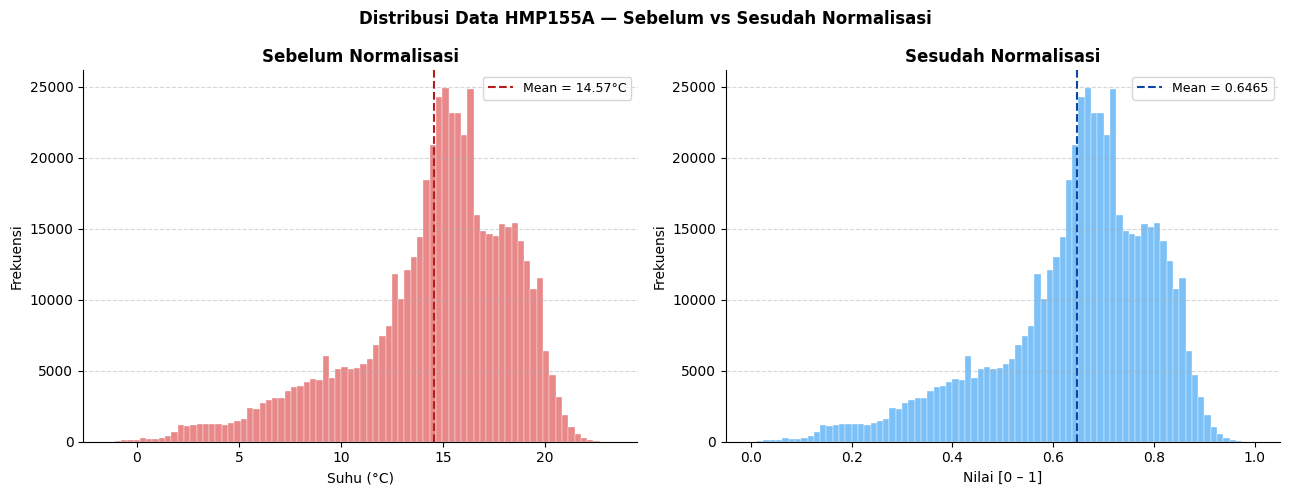

Grafik disimpan: distribusi_normalisasi_HMP155A.png
Total data divisualisasikan: 537718 baris


In [ ]:
df_train_out = train_data.copy()
df_train_out['Split']        = 'Train'
df_train_out['HMP155A_norm'] = train_scaled.flatten()

df_val_out = val_data.copy()
df_val_out['Split']        = 'Validation'
df_val_out['HMP155A_norm'] = val_scaled.flatten()

df_test_out = test_data.copy()
df_test_out['Split']        = 'Test'
df_test_out['HMP155A_norm'] = test_scaled.flatten()

df_all = pd.concat([df_train_out, df_val_out, df_test_out])

# ── Grafik distribusi sebelum & sesudah normalisasi (seluruh data) ─
all_original = df_all['HMP155A'].values
all_norm     = df_all['HMP155A_norm'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Data HMP155A — Sebelum vs Sesudah Normalisasi',
             fontsize=12, fontweight='bold')

# Sebelum normalisasi
axes[0].hist(all_original, bins=80,
             color='#E57373', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].set_title('Sebelum Normalisasi', fontweight='bold')
axes[0].set_xlabel('Suhu (°C)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(all_original.mean(), color='#B71C1C', linestyle='--',
                linewidth=1.5, label=f'Mean = {all_original.mean():.2f}°C')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Sesudah normalisasi
axes[1].hist(all_norm, bins=80,
             color='#64B5F6', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].set_title('Sesudah Normalisasi', fontweight='bold')
axes[1].set_xlabel('Nilai [0 – 1]')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(all_norm.mean(), color='#0D47A1', linestyle='--',
                linewidth=1.5, label=f'Mean = {all_norm.mean():.4f}')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('distribusi_normalisasi_HMP155A.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan: distribusi_normalisasi_HMP155A.png')
print(f'Total data divisualisasikan: {len(all_original)} baris')

In [6]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60  # 60 menit terakhir untuk prediksi 1 menit ke depan

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

print("=== Shape Data ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

=== Shape Data ===
X_train: (322570, 60, 1), y_train: (322570, 1)
X_val  : (107484, 60, 1),   y_val  : (107484, 1)
X_test : (107484, 60, 1),  y_test : (107484, 1)


## Cell 7: Model BiLSTM
Setelah seluruh data siap, data akan masuk ke proses model prediksi BiLSTM. Model prediksi ini nantinya akan menghasilkan data aktual vs data prediksi.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# TRAINING 3x RUN — ambil model terbaik berdasarkan R² tertinggi
# ─────────────────────────────────────────────────────────────────
import time
from sklearn.metrics import r2_score

N_RUNS      = 3
all_results = []
best_r2     = -float('inf')
best_history = None
best_model   = None

for run in range(1, N_RUNS + 1):
    run_seed = SEED + run
    np.random.seed(run_seed)
    tf.random.set_seed(run_seed)

    print(f"\n{'='*55}")
    print(f"  RUN {run}/{N_RUNS}  (seed={run_seed})")
    print(f"{'='*55}")

    m = Sequential([
        Bidirectional(LSTM(256), input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.1112),
        Dense(1)
    ])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='mse', metrics=['mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    t0 = time.time()
    hist = m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=96,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )
    elapsed = time.time() - t0

    m.save(f'degwo_bilstm_HMP155A_run{run}.keras')
    print(f"  💾 Disimpan: degwo_bilstm_HMP155A_run{run}.keras")

    y_pred_run_scaled = m.predict(X_test, verbose=0)
    y_pred_run   = scaler.inverse_transform(y_pred_run_scaled)
    y_actual_run = scaler.inverse_transform(y_test.reshape(-1, 1))
    run_r2   = r2_score(y_actual_run, y_pred_run)
    run_rmse = np.sqrt(np.mean((y_actual_run - y_pred_run)**2))
    run_mae  = np.mean(np.abs(y_actual_run - y_pred_run))
    run_mape = np.mean(np.abs((y_actual_run - y_pred_run) / y_actual_run)) * 100
    best_ep  = int(np.argmin(hist.history['val_loss'])) + 1

    print(f"\n  ✅ Run {run} selesai ({elapsed:.1f}s)")
    print(f"     R²   = {run_r2:.6f}")
    print(f"     RMSE = {run_rmse:.4f} °C")
    print(f"     MAE  = {run_mae:.4f} °C")
    print(f"     MAPE = {run_mape:.4f} %")
    print(f"     Best epoch = {best_ep}")

    all_results.append({
        'Run'          : run,
        'R2'           : run_r2,
        'RMSE'         : run_rmse,
        'MAE'          : run_mae,
        'MAPE'         : run_mape,
        'best_epoch'   : best_ep,
        'train_time_s' : round(elapsed, 2),
    })

    if run_r2 > best_r2:
        best_r2      = run_r2
        best_history = hist
        best_model   = m
        print(f"     ⭐ Model terbaik baru! (R²={run_r2:.6f})")

# ── Ringkasan 3 run ───────────────────────────────────────────────
df_runs = pd.DataFrame(all_results)

print("\n\n=== RINGKASAN 3 RUN ===")
print(df_runs[['Run','R2','RMSE','MAE','MAPE','best_epoch','train_time_s']].to_string(index=False))

print(f"\nR²   : {df_runs['R2'].mean():.6f} ± {df_runs['R2'].std():.6f}")
print(f"RMSE : {df_runs['RMSE'].mean():.4f} ± {df_runs['RMSE'].std():.4f} °C")
print(f"MAE  : {df_runs['MAE'].mean():.4f} ± {df_runs['MAE'].std():.4f} °C")
print(f"MAPE : {df_runs['MAPE'].mean():.4f} ± {df_runs['MAPE'].std():.4f} %")

best_run = df_runs.loc[df_runs['R2'].idxmax(), 'Run']
print(f"\nModel terbaik : Run {int(best_run)} (R²={best_r2:.6f})")

save_to_excel(df_runs, 'ringkasan_3run_DEGWO_BILSTM_HMP155A.xlsx',
              sheet_name='3 Run Summary', index=False)

model   = best_model
history = best_history

print(f"\n✅ Model terbaik siap digunakan untuk evaluasi selanjutnya.")


  RUN 1/3  (seed=43)
Epoch 1/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 65s 18ms/step - loss: 0.0019 - mae: 0.0234 - val_loss: 1.4980e-04 - val_mae: 0.0080
Epoch 2/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 61s 18ms/step - loss: 4.0272e-04 - mae: 0.0152 - val_loss: 9.9917e-05 - val_mae: 0.0065
Epoch 3/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 61s 18ms/step - loss: 3.0393e-04 - mae: 0.0132 - val_loss: 7.6946e-05 - val_mae: 0.0057
Epoch 4/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 61s 18ms/step - loss: 2.5949e-04 - mae: 0.0123 - val_loss: 1.0214e-04 - val_mae: 0.0079
Epoch 5/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - loss: 2.2932e-04 - mae: 0.0115 - val_loss: 5.8626e-05 - val_mae: 0.0053
Epoch 6/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - loss: 2.0813e-04 - mae: 0.0110 - val_loss: 7.3258e-05 - val_mae: 0.0067
Epoch 7/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - loss: 1.9320e-04 - mae: 0.0106 - val_loss: 3.9119e-05 - val_mae: 0.0041
Epoch 8/50
3361/3361 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - loss: 1.7888e-

## Cell 8-9 - Training & Validation Loss


=== Training History ===
Epoch    Train Loss     Val Loss       Train MAE      Val MAE
------------------------------------------------------------
1        0.002083       0.000184       0.023953       0.009517
2        0.000409       0.000109       0.015282       0.007297
3        0.000311       0.000223       0.013360       0.013215
4        0.000262       0.000062       0.012312       0.005344
5        0.000230       0.000214       0.011547       0.013323
6        0.000209       0.000052       0.011007       0.005333
7        0.000194       0.000061       0.010601       0.006274
8        0.000178       0.000083       0.010149       0.007717
9        0.000168       0.000078       0.009846       0.007571
10       0.000161       0.000045       0.009618       0.005160
11       0.000155       0.000032       0.009413       0.003684
12       0.000150       0.000030       0.009241       0.003293
13       0.000145       0.000038       0.009063       0.004552
14       0.000141       0.000030

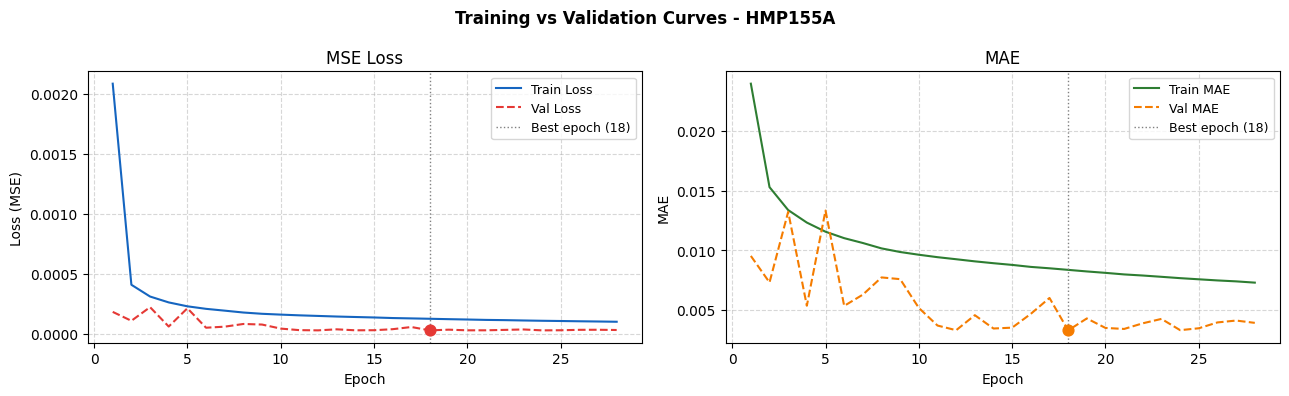


Grafik berhasil disimpan sebagai: training_curves_degwo_bilstm_hmp115a_detailed.png


In [ ]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_mae  = history.history['mae']
val_mae    = history.history['val_mae']
epochs     = range(1, len(train_loss) + 1)

# ── Cari nilai minimum (Best Epoch) ─────────────────
best_epoch_loss = int(np.argmin(val_loss)) + 1
best_epoch_mae  = int(np.argmin(val_mae))  + 1

# ═══════════════════════════════════════════════════
# 1. Print Tabel History Tiap Epoch
# ═══════════════════════════════════════════════════
print("\n=== Training History ===")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Train MAE':<14} {'Val MAE'}")
print("-" * 60)
for e, tl, vl, tm, vm in zip(epochs, train_loss, val_loss, train_mae, val_mae):
    marker = " ◄ best val_loss" if e == best_epoch_loss else ""
    print(f"{e:<8} {tl:<14.6f} {vl:<14.6f} {tm:<14.6f} {vm:.6f}{marker}")

print(f"\nBest Val Loss : {min(val_loss):.6f}  (epoch {best_epoch_loss})")
print(f"Best Val MAE  : {min(val_mae):.6f}  (epoch {best_epoch_mae})")

# ═══════════════════════════════════════════════════
# 2. Deteksi Overfitting Secara Otomatis
# ═══════════════════════════════════════════════════
train_loss_final = train_loss[-1]
val_loss_final   = val_loss[-1]
train_mae_final  = train_mae[-1]
val_mae_final    = val_mae[-1]

gap_loss = val_loss_final - train_loss_final
gap_mae  = val_mae_final  - train_mae_final
ratio    = val_loss_final / train_loss_final

print("\n=== Deteksi Overfitting ===")
print(f"Final Train Loss : {train_loss_final:.6f}")
print(f"Final Val Loss   : {val_loss_final:.6f}")
print(f"Gap Loss         : {gap_loss:.6f}")
print(f"Ratio Val/Train  : {ratio:.4f}")
print(f"\nFinal Train MAE  : {train_mae_final:.4f} °C")
print(f"Final Val MAE    : {val_mae_final:.4f} °C")
print(f"Gap MAE          : {gap_mae:.4f} °C")

print("\n=== Kesimpulan ===")
if ratio < 1.1:
    print("✅ GOOD FIT — model belajar dengan baik, tidak overfitting")
elif ratio < 1.5:
    print("⚠️  SLIGHT OVERFIT — sedikit overfitting, masih tolerabel")
else:
    print("❌ OVERFIT — val loss jauh lebih besar dari train loss")

if val_loss_final < train_loss_final:
    print("ℹ️  Val loss lebih kecil dari train loss — kemungkinan underfitting")
    print("   Coba tambah kapasitas model atau kurangi dropout")

    'Epoch'      : list(epochs),
    'Train_Loss' : train_loss,
    'Val_Loss'   : val_loss,
    'Train_MAE'  : train_mae,
    'Val_MAE'    : val_mae
})
save_to_excel(df_hist, 'training_history_degwo_bilstm_HMP155A.xlsx', sheet_name='Training History', index=False)

# ═══════════════════════════════════════════════════
# 3. Plot Grafik Gaya Baru
# ═══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training vs Validation Curves - HMP155A', fontsize=12, fontweight='bold')

# --- Plot Loss ---
axes[0].plot(epochs, train_loss, color='#1565C0', linewidth=1.5, label='Train Loss')
axes[0].plot(epochs, val_loss,   color='#E53935', linewidth=1.5, linestyle='--', label='Val Loss')
axes[0].axvline(best_epoch_loss, color='grey', linestyle=':', linewidth=1,
                label=f'Best epoch ({best_epoch_loss})')
axes[0].scatter([best_epoch_loss], [val_loss[best_epoch_loss-1]],
                color='#E53935', zorder=5, s=60)
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot MAE ---
axes[1].plot(epochs, train_mae, color='#2E7D32', linewidth=1.5, label='Train MAE')
axes[1].plot(epochs, val_mae,   color='#F57C00', linewidth=1.5, linestyle='--', label='Val MAE')
axes[1].axvline(best_epoch_mae, color='grey', linestyle=':', linewidth=1,
                label=f'Best epoch ({best_epoch_mae})')
axes[1].scatter([best_epoch_mae], [val_mae[best_epoch_mae-1]],
                color='#F57C00', zorder=5, s=60)
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_curves_degwo_bilstm_hmp115a_detailed.png', dpi=150)
plt.show()
print("\nGrafik berhasil disimpan sebagai: training_curves_degwo_bilstm_hmp115a_detailed.png")

  Diagnosis Overfit / Underfit — Loss Curve
  Best val_loss  : 0.000030  (epoch 18)
  Final train_loss : 0.000101
  Final val_loss   : 0.000033
  Gap (val - train): -0.000069

  >>> OVERFIT
       Val loss naik lagi setelah epoch 18 — model mulai hafal data training


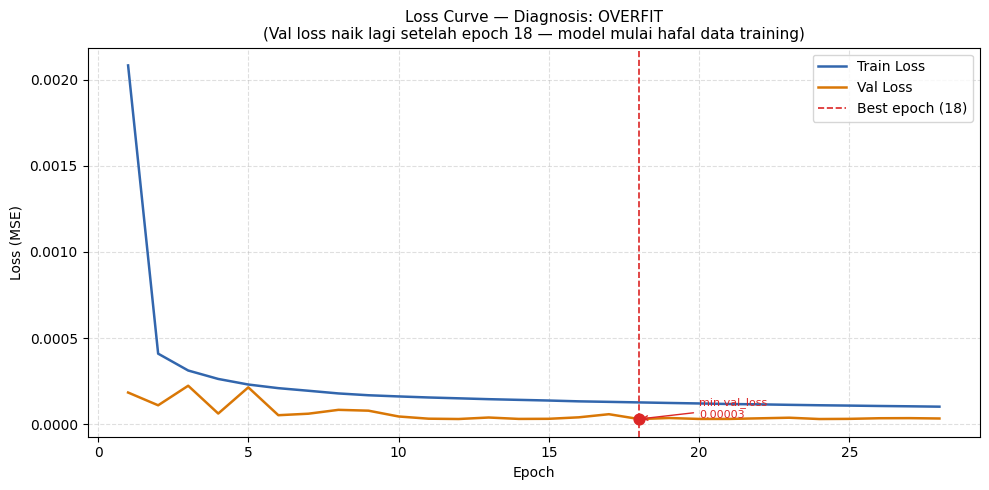

In [ ]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
epochs     = range(1, len(train_loss) + 1)

best_epoch    = int(np.argmin(val_loss))
val_loss_min  = val_loss[best_epoch]
val_loss_last = val_loss[-1]
train_loss_last = train_loss[-1]
gap_last      = val_loss_last - train_loss_last

# ── Diagnosis ─────────────────────────────────────────────────
print("=" * 55)
print("  Diagnosis Overfit / Underfit — Loss Curve")
print("=" * 55)
print(f"  Best val_loss  : {val_loss_min:.6f}  (epoch {best_epoch + 1})")
print(f"  Final train_loss : {train_loss_last:.6f}")
print(f"  Final val_loss   : {val_loss_last:.6f}")
print(f"  Gap (val - train): {gap_last:.6f}")

if train_loss_last > 0.01 and val_loss_last > 0.01:
    diagnosis  = "UNDERFIT"
    keterangan = "Train loss masih tinggi — model belum cukup belajar"
elif val_loss_last > val_loss_min * 1.05:
    diagnosis  = "OVERFIT"
    keterangan = f"Val loss naik lagi setelah epoch {best_epoch + 1} — model mulai hafal data training"
else:
    diagnosis  = "GOOD FIT"
    keterangan = "Train loss dan val loss konvergen di titik yang sama"

print(f"\n  >>> {diagnosis}")
print(f"       {keterangan}")
print("=" * 55)

# ── Plot loss curve ─────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, label='Train Loss', color='#3266ad', linewidth=1.8)
ax.plot(epochs, val_loss,   label='Val Loss',   color='#d97706', linewidth=1.8)

ax.axvline(x=best_epoch + 1, color='#dc2626', linestyle='--',
           linewidth=1.2, label=f'Best epoch ({best_epoch + 1})')
ax.scatter([best_epoch + 1], [val_loss_min], color='#dc2626', zorder=5, s=60)
ax.annotate(f'min val_loss\n{val_loss_min:.5f}',
            xy=(best_epoch + 1, val_loss_min),
            xytext=(best_epoch + 3, val_loss_min * 1.3),
            fontsize=8, color='#dc2626',
            arrowprops=dict(arrowstyle='->', color='#dc2626'))

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title(f'Loss Curve — Diagnosis: {diagnosis}\n({keterangan})', fontsize=11)
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('diagnosis_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10-11: Evaluate Model

3359/3359 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step
=== Evaluasi Model pada Test Set ===
MAE  : 0.0957 °C
RMSE : 0.1485 °C
MAPE : 0.6259 %
R²   : 0.9978
  ✅ Disimpan: model_metrics_DEGWO-BILSTM_HMP155A.xlsx


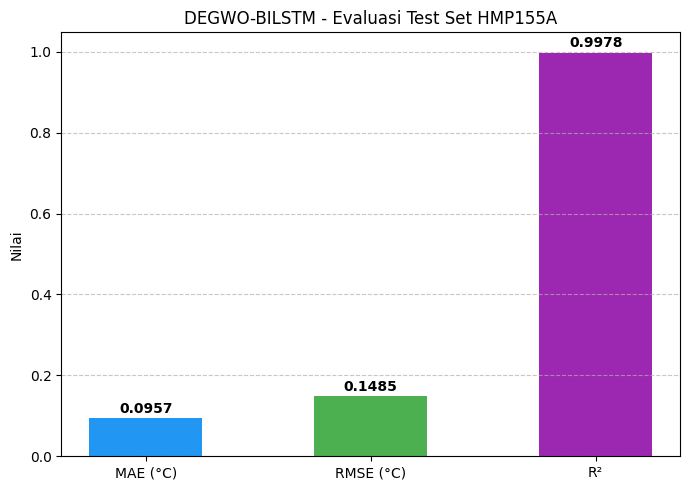

In [ ]:
# Prediksi pada test set
y_pred_scaled = model.predict(X_test)

y_pred   = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae    = mean_absolute_error(y_actual, y_pred)
rmse   = np.sqrt(mean_squared_error(y_actual, y_pred))
mape   = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
r2     = r2_score(y_actual, y_pred)

print("=== Evaluasi Model pada Test Set ===")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"MAPE : {mape:.4f} %")
print(f"R²   : {r2:.4f}")

df_metrics = pd.DataFrame({
    'Metrik' : ['MAE (°C)', 'RMSE (°C)', 'MAPE (%)', 'R²'],
    'Nilai'  : [mae, rmse, mape, r2]
})
save_to_excel(df_metrics, 'model_metrics_DEGWO-BILSTM_HMP155A.xlsx', sheet_name='Metrik', index=False)

# Bar Chart Metrik
fig, ax = plt.subplots(figsize=(7, 5))

metrics_names  = ['MAE (°C)', 'RMSE (°C)', 'R²']
metrics_values = [mae, rmse, r2]
colors         = ['#2196F3', '#4CAF50', '#9C27B0']

bars = ax.bar(metrics_names, metrics_values, color=colors, width=0.5)
ax.set_title('DEGWO-BILSTM - Evaluasi Test Set HMP155A')
ax.set_ylabel('Nilai')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar, val in zip(bars, metrics_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('bar_chart_metrik_DEGWO-BILSTM_HMP155A.png', dpi=150)
plt.show()

  Perbandingan Metrik: Train / Validation / Test
Metrik            Train   Validation       Test
------------------------------------------------------------
MAE (°C)         0.1343       0.0810     0.0957
RMSE (°C)        0.2046       0.1345     0.1485
MAPE (%)            inf       0.5227     0.6259
R²               0.9978       0.9967     0.9978

=== Diagnosis ===
  Gap MAE  (Val - Train) : 0.0533 °C
  Gap RMSE (Val - Train) : 0.0701 °C
  Gap R²   (Val - Train) : 0.0011

  >>> FIT      — performa training dan validation relatif seimbang


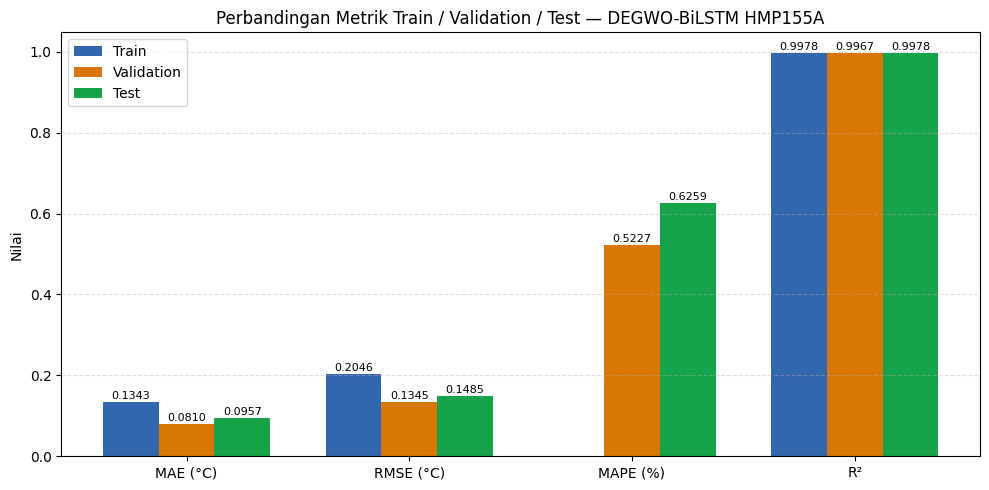

In [ ]:
# ── Prediksi pada train & val set ────────────────────────────
y_train_pred_scaled = best_model.predict(X_train, verbose=0)
y_val_pred_scaled   = best_model.predict(X_val,   verbose=0)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_train_pred   = scaler.inverse_transform(y_train_pred_scaled)
y_val_actual   = scaler.inverse_transform(y_val.reshape(-1, 1))
y_val_pred     = scaler.inverse_transform(y_val_pred_scaled)

# Metrik
def hitung_metrik(actual, pred):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    r2   = r2_score(actual, pred)
    return mae, rmse, mape, r2

mae_tr, rmse_tr, mape_tr, r2_tr = hitung_metrik(y_train_actual, y_train_pred)
mae_vl, rmse_vl, mape_vl, r2_vl = hitung_metrik(y_val_actual,   y_val_pred)

# mae, rmse, mape, r2 dari Cell 10 = test set
mae_ts, rmse_ts, mape_ts, r2_ts = mae, rmse, mape, r2

print("=" * 60)
print("  Perbandingan Metrik: Train / Validation / Test")
print("=" * 60)
print(f"{'Metrik':<12} {'Train':>10} {'Validation':>12} {'Test':>10}")
print("-" * 60)
print(f"{'MAE (°C)':<12} {mae_tr:>10.4f} {mae_vl:>12.4f} {mae_ts:>10.4f}")
print(f"{'RMSE (°C)':<12} {rmse_tr:>10.4f} {rmse_vl:>12.4f} {rmse_ts:>10.4f}")
print(f"{'MAPE (%)':<12} {mape_tr:>10.4f} {mape_vl:>12.4f} {mape_ts:>10.4f}")
print(f"{'R²':<12} {r2_tr:>10.4f} {r2_vl:>12.4f} {r2_ts:>10.4f}")
print("=" * 60)

gap_mae  = abs(mae_vl  - mae_tr)
gap_rmse = abs(rmse_vl - rmse_tr)
gap_r2   = abs(r2_vl   - r2_tr)

print("\n=== Diagnosis ===")
if r2_tr < 0.80:
    diagnosis = "UNDERFIT — model belum cukup belajar dari data training"
elif gap_r2 > 0.10 or gap_rmse > 0.5:
    diagnosis = "OVERFIT  — performa training jauh lebih baik dari validation"
else:
    diagnosis = "FIT      — performa training dan validation relatif seimbang"

print(f"  Gap MAE  (Val - Train) : {gap_mae:.4f} °C")
print(f"  Gap RMSE (Val - Train) : {gap_rmse:.4f} °C")
print(f"  Gap R²   (Val - Train) : {gap_r2:.4f}")
print(f"\n  >>> {diagnosis}")

metrik_names = ['MAE (°C)', 'RMSE (°C)', 'MAPE (%)', 'R²']
train_vals   = [mae_tr,  rmse_tr,  mape_tr,  r2_tr]
val_vals     = [mae_vl,  rmse_vl,  mape_vl,  r2_vl]
test_vals    = [mae_ts,  rmse_ts,  mape_ts,  r2_ts]

x     = np.arange(len(metrik_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, train_vals, width, label='Train',      color='#3266ad')
b2 = ax.bar(x,         val_vals,   width, label='Validation', color='#d97706')
b3 = ax.bar(x + width, test_vals,  width, label='Test',       color='#16a34a')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrik_names)
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Metrik Train / Validation / Test — DEGWO-BiLSTM HMP155A')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('metrik_train_val_test_DEGWO-BILSTM_HMP155A.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12-15: Actual vs Predicted Plot




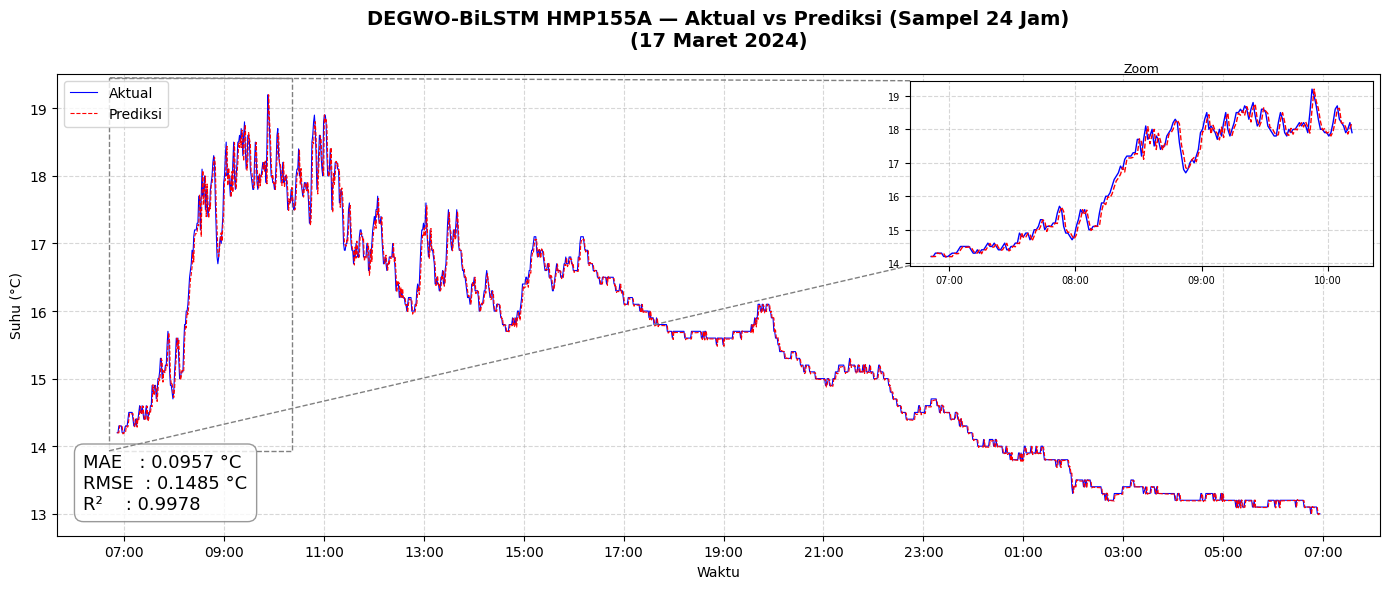

  ✅ Disimpan: aktual_vs_prediksi_DEGWO-BILSTM_HMP155A.xlsx


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

sample     = 1440
time_index = test_data.index[WINDOW_SIZE:WINDOW_SIZE + sample]

fig, ax = plt.subplots(figsize=(14, 6)) # Tinggi sedikit ditambah agar lebih lega

# Plot utama
ax.plot(time_index, y_actual[:sample],
        label='Aktual', color='blue', linewidth=0.8)
ax.plot(time_index, y_pred[:sample],
        label='Prediksi', color='red', linewidth=0.8, linestyle='--')

info_text = (
    f"MAE   : {mae:.4f} °C\n"
    f"RMSE  : {rmse:.4f} °C\n"
    f"R²    : {r2:.4f}"
)

ax.text(0.02, 0.05, info_text, transform=ax.transAxes, fontsize=13,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
# ────────────────────────────────────────────────────────────────

ax.set_xlabel('Waktu')
ax.set_ylabel('Suhu (°C)')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=0)

# Format waktu
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
BULAN_ID = {
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April',
    5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus',
    9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
}

t = time_index[0]
tanggal = f"{t.day} {BULAN_ID[t.month]} {t.year}"
ax.set_title(f'DEGWO-BiLSTM HMP155A — Aktual vs Prediksi (Sampel 24 Jam)\n({tanggal})', fontsize=14, fontweight='bold', pad=20)

# Inset — zoom 200 sampel pertama
inset_start = 0
inset_end   = 200

ax_inset = inset_axes(ax, width='35%', height='40%', loc='upper right')
ax_inset.plot(time_index[inset_start:inset_end],
              y_actual[inset_start:inset_end],
              color='blue', linewidth=1)
ax_inset.plot(time_index[inset_start:inset_end],
              y_pred[inset_start:inset_end],
              color='red', linewidth=1, linestyle='--')
ax_inset.set_title('Zoom', fontsize=9)
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_inset.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax_inset.tick_params(axis='x', rotation=0, labelsize=7)
ax_inset.tick_params(axis='y', labelsize=7)
ax_inset.grid(True, linestyle='--', alpha=0.5)

mark_inset(ax, ax_inset, loc1=2, loc2=3, fc='none', ec='gray', linestyle='--')

plt.tight_layout()
plt.savefig('aktual_vs_prediksi_DEGWO-BILSTM_HMP155A.png', dpi=150)
plt.show()

df_pred_out = pd.DataFrame({
    'Waktu'      : time_index,
    'Aktual_C'   : y_actual[:sample].flatten(),
    'Prediksi_C' : y_pred[:sample].flatten()
}).set_index('Waktu')
save_to_excel(df_pred_out, 'aktual_vs_prediksi_DEGWO-BILSTM_HMP155A.xlsx', sheet_name='Aktual vs Prediksi')

In [14]:
time_index_all = test_data.index[WINDOW_SIZE : WINDOW_SIZE + len(y_actual)]

df_aktual_vs_prediksi = pd.DataFrame({
    'Aktual (°C)'   : y_actual.flatten(),
    'Prediksi (°C)' : y_pred.flatten(),
    'Residual (°C)' : (y_actual - y_pred).flatten(),
    '|Residual|'    : np.abs(y_actual - y_pred).flatten(),
}, index=time_index_all)

df_aktual_vs_prediksi.index.name = 'Time'

save_to_excel(df_aktual_vs_prediksi,
              'aktual_vs_prediksi_DEGWO-BILSTM_HMP155A_ALL.xlsx',
              sheet_name='Aktual vs Prediksi',
              index=True)

print(f'✅ Tersimpan: aktual_vs_prediksi_DEGWO-BILSTM_HMP155A_ALL.xlsx')
print(f'   Total baris : {len(df_aktual_vs_prediksi):,}')
print(f'   Rentang     : {time_index_all[0]}  →  {time_index_all[-1]}')

  ✅ Disimpan: aktual_vs_prediksi_DEGWO-BILSTM_HMP155A_ALL.xlsx
✅ Tersimpan: aktual_vs_prediksi_DEGWO-BILSTM_HMP155A_ALL.xlsx
   Total baris : 107,484
   Rentang     : 2024-03-17 06:51:24  →  2024-05-31 06:59:23


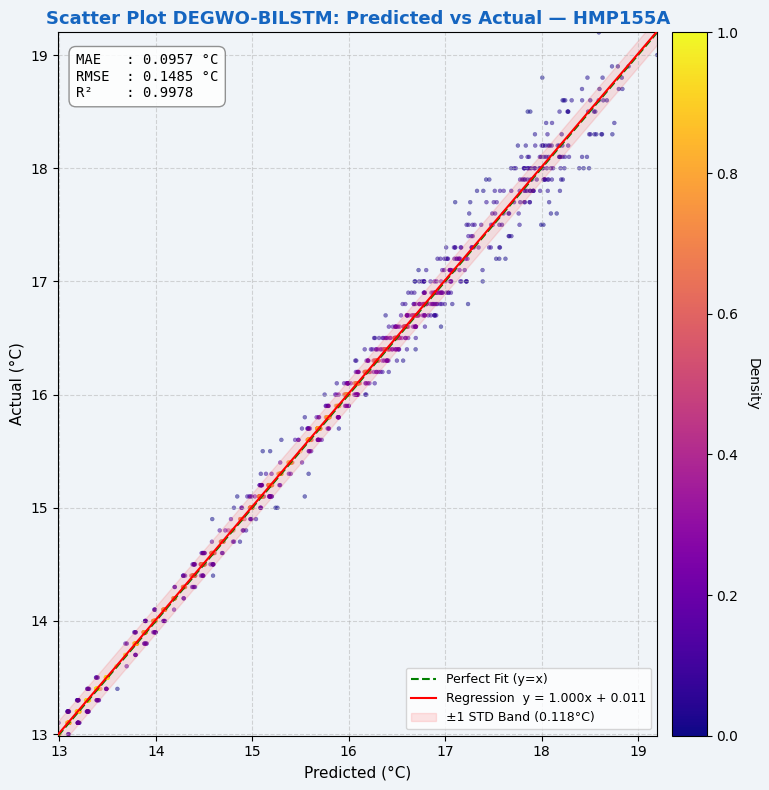

In [ ]:
from scipy.stats import gaussian_kde

xy      = np.vstack([y_pred[:sample].flatten(), y_actual[:sample].flatten()])
density = gaussian_kde(xy)(xy)

density_norm = (density - density.min()) / (density.max() - density.min())

# ── Regresi linear ────────────────────────────────────────────────
slope, intercept, _, _, _ = stats.linregress(
    y_pred[:sample].flatten(), y_actual[:sample].flatten()
)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#F0F4F8')

# Scatter — titik hollow (tidak terisi), warna border dari density
sc = ax.scatter(
    y_pred[:sample].flatten(),
    y_actual[:sample].flatten(),
    c=density_norm,
    cmap='plasma',
    s=8,
    alpha=0.5,
    linewidths=0.3,
    facecolors='none',       # hollow / tidak terisi
    edgecolors=plt.cm.plasma(density_norm)
)

# Perfect fit (y = x)
lims = [
    min(y_pred[:sample].min(), y_actual[:sample].min()),
    max(y_pred[:sample].max(), y_actual[:sample].max())
]
ax.plot(lims, lims, 'g--', linewidth=1.5, label='Perfect Fit (y=x)', zorder=3)

# Regression line
x_line = np.linspace(lims[0], lims[1], 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='red', linewidth=1.5,
        label=f'Regression  y = {slope:.3f}x + {intercept:.3f}', zorder=3)

# ±1 STD band
std_res = np.std(y_actual[:sample].flatten() - y_pred[:sample].flatten())
ax.fill_between(x_line, y_line - std_res, y_line + std_res,
                color='red', alpha=0.10,
                label=f'±1 STD Band ({std_res:.3f}°C)')

cbar = plt.colorbar(
    plt.cm.ScalarMappable(
        cmap='plasma',
        norm=plt.Normalize(density_norm.min(), density_norm.max())
    ),
    ax=ax, pad=0.02
)
cbar.set_label('Density', rotation=270, labelpad=15)

# Info box metrik
info_text = (
    f'MAE   : {mae:.4f} °C\n'
    f'RMSE  : {rmse:.4f} °C\n'
    f'R²    : {r2:.4f}'
)
ax.text(0.03, 0.97, info_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'),
        fontfamily='monospace')

ax.set_xlabel('Predicted (°C)', fontsize=11)
ax.set_ylabel('Actual (°C)', fontsize=11)
ax.set_title('Scatter Plot DEGWO-BILSTM: Predicted vs Actual — HMP155A',
             fontsize=13, fontweight='bold', color='#1565C0')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('scatter_predicted_vs_actual_sampel.png', dpi=150, bbox_inches='tight')
plt.show()

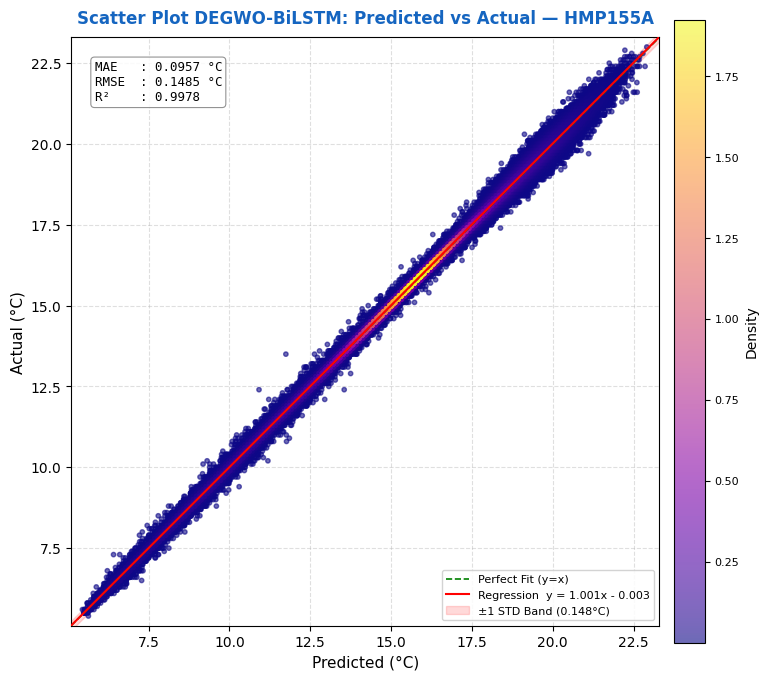

Scatter plot disimpan: scatter_predicted_vs_actual_ALL.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

xy      = np.vstack([y_pred.flatten(), y_actual.flatten()])
density = stats.gaussian_kde(xy)(xy)
idx     = density.argsort()

sc = ax.scatter(
    y_pred.flatten()[idx],
    y_actual.flatten()[idx],
    c=density[idx],
    cmap='plasma',
    s=10,        # ↓ dari 15 → titik lebih kecil, overplot berkurang
    alpha=0.6,   # ↓ sedikit biar lapisan bawah tetap kelihatan
    zorder=3
)
cbar = plt.colorbar(sc, ax=ax, label='Density', pad=0.02)
cbar.ax.tick_params(labelsize=8)

# ── Perfect fit line (y = x) ─────────────────────────────────────
pad  = 0.3
lims = [
    min(y_pred.min(), y_actual.min()) - pad,
    max(y_pred.max(), y_actual.max()) + pad
]
ax.plot(lims, lims, 'g--', linewidth=1.2, label='Perfect Fit (y=x)', zorder=4)

# ── Regression line ──────────────────────────────────────────────
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
    y_pred.flatten(), y_actual.flatten()
)
x_line = np.linspace(lims[0], lims[1], 200)
y_line = slope * x_line + intercept
sign   = '+' if intercept >= 0 else '-'   # ← tanda minus tidak double
ax.plot(
    x_line, y_line,
    color='red', linewidth=1.5,
    label=f'Regression  y = {slope:.3f}x {sign} {abs(intercept):.3f}',
    zorder=5
)

# ── ±1 STD band ──────────────────────────────────────────────────
residuals_reg = y_actual.flatten() - (slope * y_pred.flatten() + intercept)
std_reg       = np.std(residuals_reg)
ax.fill_between(
    x_line,
    y_line - std_reg,
    y_line + std_reg,
    alpha=0.15, color='red',
    label=f'±1 STD Band ({std_reg:.3f}°C)'
)

# ── Metrics box ──────────────────────────────────────────────────
metrics_text = (
    f"MAE   : {mae:.4f} °C\n"
    f"RMSE  : {rmse:.4f} °C\n"
    f"R²    : {r2:.4f}"
)
ax.text(
    0.04, 0.96, metrics_text,
    transform=ax.transAxes,
    fontsize=9, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
              edgecolor='grey', linewidth=0.8),
    fontfamily='monospace',
    zorder=6
)


ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Predicted (°C)', fontsize=11)
ax.set_ylabel('Actual (°C)', fontsize=11)
ax.set_title(
    'Scatter Plot DEGWO-BiLSTM: Predicted vs Actual — HMP155A',
    fontweight='bold', fontsize=12, color='#1565C0', pad=10
)
ax.legend(fontsize=8, loc='lower right', framealpha=0.85)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(
    'scatter_predicted_vs_actual_ALL.png',
    dpi=150, bbox_inches='tight',
    facecolor='white'
)
plt.show()
print("Scatter plot disimpan: scatter_predicted_vs_actual_ALL.png")

## Cell 16-21: Deteksi Sensor
Setelah model prediksi selesai, dihitung residual dari validation set yaitu selisih antara nilai aktual dan nilai prediksi. Kemudian, nilai residual_val ini akan digunakan untuk menghitung mu_residual dan sigma. Data validation digunakan agar memastikan bahwa deteksi anomali yang dilakukan di data test dilakukan secara konsisten terhadap referensi kondisi normal yang tetap.

In [ ]:
y_val_pred_scaled = model.predict(X_val, verbose=0)

y_val_pred   = scaler.inverse_transform(y_val_pred_scaled)
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

residuals_val = y_val_actual - y_val_pred
mu_residual = float(np.mean(residuals_val))
sigma       = float(np.std(residuals_val))

print('=' * 55)
print('  Threshold dari Residual Validation Set')
print('=' * 55)
print(f'  Mean residual (μ)      : {mu_residual:.4f} °C')
print(f'  Sigma (σ)              : {sigma:.4f} °C')
print(f'  Warning threshold ±2σ  : ±{2*sigma:.4f} °C')
print(f'  Fault threshold   ±3σ  : ±{3*sigma:.4f} °C')
print('=' * 55)
print()
print('  Step 1 : Distribusi Chi-Squared W = Σ z²  =  Σ ((r_i - μ) / σ)²')
print('  Step 2 : z = (residual - μ) / σ')
print(f'  |z| ≤ 2  → NORMAL')
print(f'  |z| ≤ 3  → WARNING')
print(f'  |z| > 3  → FAULT')

  Threshold dari Residual Validation Set
  Mean residual (μ)      : 0.0105 °C
  Sigma (σ)              : 0.1340 °C
  Warning threshold ±2σ  : ±0.2681 °C
  Fault threshold   ±3σ  : ±0.4021 °C

  Step 1 : Distribusi Chi-Squared W = Σ z²  =  Σ ((r_i - μ) / σ)²
  Step 2 : z = (residual - μ) / σ
  |z| ≤ 2  → NORMAL
  |z| ≤ 3  → WARNING
  |z| > 3  → FAULT


Setelah ditentukan nilai mu_residual dan sigma, dilakukan deteksi anomali menggunakan uji statistik chi-squared untuk deteksi window-level dan z-score threshold untuk deteksi data point-level.

In [ ]:
def deteksi_anomali(data_aktual, data_prediksi, sigma, mu_residual,
                    window_size=10):
    """
    Step 1 — Window level: Distribusi Chi-Squared
              W = Σ z²  =  Σ ((r_i - μ) / σ)²

    Step 2 — Data point level: Z-Score
              z = (residual - μ) / σ
              di mana μ dan σ dari residual validation set
              |z| ≤ 2  → dalam interval μ ± 2σ → Normal
              |z| ≤ 3  → dalam interval μ ± 3σ → Warning
              |z| > 3  → di luar interval μ ± 3σ → Fault

    Parameters
    ----------
    data_aktual   : array nilai aktual sensor (O)
    data_prediksi : array nilai prediksi BiLSTM (E)
    sigma         : std deviasi residual dari validation set (σ)
    mu_residual   : mean residual dari validation set (μ)
    window_size   : ukuran sliding window (default 10)
    """
    n     = len(data_aktual)
    hasil = []

    for i in range(n):
        aktual   = data_aktual[i]
        prediksi = data_prediksi[i]

        # ── Step 1: Distribusi Chi-Squared Window Level ───────────
        win_start = max(0, i - window_size + 1)
        win_end   = i + 1

        if (win_end - win_start) < window_size:
            hasil.append({
                'aktual'   : aktual,
                'prediksi' : prediksi,
                'residual' : aktual - prediksi,
                'z_score'  : (aktual - prediksi - mu_residual) / sigma,
                'z_window' : np.nan,
                'p_value'  : np.nan,
                'status'   : 'Normal'  # belum cukup data, skip dulu
            })
            continue

        residuals_window = (data_aktual[win_start:win_end] -
                            data_prediksi[win_start:win_end])

        z_scores_window = (residuals_window - mu_residual) / sigma
        z_window        = np.sum(z_scores_window ** 2)

        actual_df = win_end - win_start
        p_value   = 1 - stats.chi2.cdf(z_window, df=max(1, actual_df))

        # Step 2: cek apakah residual berada dalam prediction interval
        residual = aktual - prediksi
        z_score  = (residual - mu_residual) / sigma

        if p_value >= 0.05:
            status = 'Normal'
        else:
            abs_z = abs(z_score)
            if abs_z <= 2:
                status = 'Normal'
            elif abs_z <= 3:
                status = 'Warning'
            else:
                status = 'Fault'

        hasil.append({
            'aktual'   : aktual,
            'prediksi' : prediksi,
            'residual' : residual,
            'z_score'  : z_score,
            'z_window' : z_window,
            'p_value'  : p_value,
            'status'   : status
        })

    df_hasil = pd.DataFrame(hasil)

    # ── Sensor Failure Detection ───────────────────────────────────
    df_hasil['sensor_failure'] = False
    consecutive = 0
    for i in range(len(df_hasil)):
        if df_hasil.loc[i, 'status'] == 'Fault':
            consecutive += 1
            if consecutive >= 3:
                df_hasil.loc[i-2:i, 'sensor_failure'] = True
        else:
            consecutive = 0

    return df_hasil

print('=== Fungsi Deteksi Siap ===')
print('  Step 1 : W = Σ z²  =  Σ ((r_i - μ) / σ)²  →  p-value vs α = 0.05')
print('  Step 2 : z = (residual − μ) / σ  →  threshold |z| = 2 dan |z| = 3')
print('  μ, σ   : dihitung dari residual validation set')

=== Fungsi Deteksi Siap ===
  Step 1 : W = Σ z²  =  Σ ((r_i - μ) / σ)²  →  p-value vs α = 0.05
  Step 2 : z = (residual − μ) / σ  →  threshold |z| = 2 dan |z| = 3
  μ, σ   : dihitung dari residual validation set
  Failure: Fault berturut-turut ≥ 3 data point


In [ ]:
df_deteksi = deteksi_anomali(
    data_aktual   = y_actual.flatten(),
    data_prediksi = y_pred.flatten(),
    sigma         = sigma,
    mu_residual   = mu_residual,
    window_size   = 10
)

df_deteksi.index = test_data.index[WINDOW_SIZE:WINDOW_SIZE + len(df_deteksi)]

distribusi = collections.Counter(df_deteksi['status'])
total      = len(df_deteksi)
n_failure  = df_deteksi['sensor_failure'].sum()

print('=== Hasil Deteksi Anomali pada Test Set ===')
print(f'Normal  : {distribusi.get("Normal",  0):>6} ({distribusi.get("Normal",  0)/total*100:.2f}%)')
print(f'Warning : {distribusi.get("Warning", 0):>6} ({distribusi.get("Warning", 0)/total*100:.2f}%)')
print(f'Fault   : {distribusi.get("Fault",   0):>6} ({distribusi.get("Fault",   0)/total*100:.2f}%)')
print(f'\nSensor Failure terdeteksi: {n_failure} data point')

save_to_excel(df_deteksi, 'hasil_deteksi_anomali_DEGWO-BILSTM_HMP155A.xlsx', sheet_name='Deteksi Anomali')

df_deteksi.head(20)

=== Hasil Deteksi Anomali pada Test Set ===
Normal  : 100624 (93.62%)
Fault   :   2891 (2.69%)

Sensor Failure terdeteksi: 172 data point
  ✅ Disimpan: hasil_deteksi_anomali_DEGWO-BILSTM_HMP155A.xlsx


,aktual,prediksi,residual,z_score,z_window,p_value,status,sensor_failure
Time,,,,,,,,
2024-03-17 06:51:24,14.2,14.200244,-0.000244,-0.080081,NaN,NaN,Normal,False
2024-03-17 06:52:24,14.2,14.197978,0.002022,-0.063177,NaN,NaN,Normal,False
2024-03-17 06:53:27,14.3,14.197894,0.102106,0.683461,NaN,NaN,Normal,False
2024-03-17 06:54:24,14.3,14.304056,-0.004056,-0.108520,NaN,NaN,Normal,False
2024-03-17 06:55:24,14.3,14.286736,0.013264,0.020686,NaN,NaN,Normal,False
2024-03-17 06:56:24,14.3,14.288136,0.011864,0.010242,NaN,NaN,Normal,False
2024-03-17 06:57:24,14.2,14.289682,-0.089682,-0.747302,NaN,NaN,Normal,False
2024-03-17 06:58:24,14.2,14.182052,0.017948,0.055636,NaN,NaN,Normal,False
2024-03-17 06:59:24,14.2,14.197637,0.002363,-0.060630,NaN,NaN,Normal,False


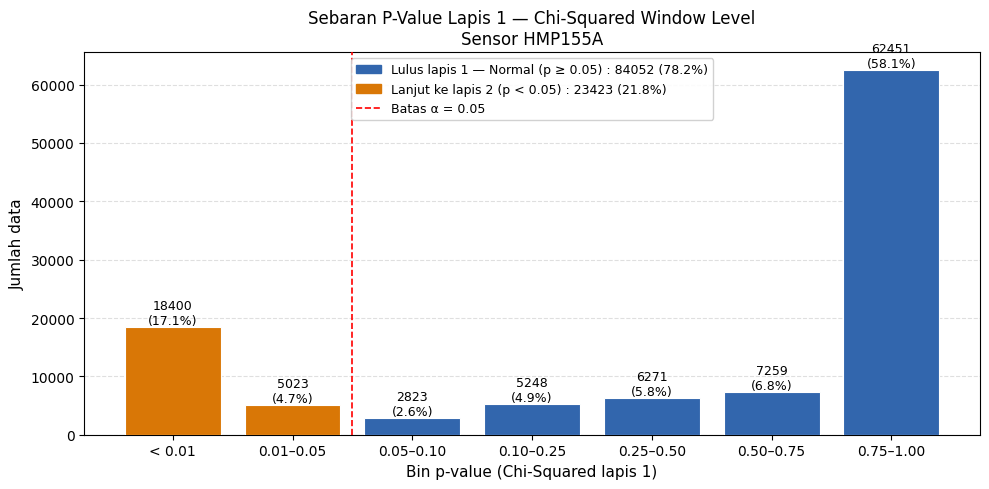

Total data (window penuh) : 107475
Lulus lapis 1 (p ≥ 0.05) : 84052 (78.21%)
Lanjut ke lapis 2 (p<0.05): 23423 (21.79%)


In [20]:
pv     = df_deteksi['p_value'].dropna()
total  = len(pv)

bins   = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.001]
labels = ['< 0.01', '0.01–0.05', '0.05–0.10', '0.10–0.25',
          '0.25–0.50', '0.50–0.75', '0.75–1.00']

counts    = pd.cut(pv, bins=bins, labels=labels, right=False).value_counts().reindex(labels)
n_lanjut  = (pv < 0.05).sum()
n_lulus   = (pv >= 0.05).sum()
colors    = ['#d97706', '#d97706', '#3266ad', '#3266ad', '#3266ad', '#3266ad', '#3266ad']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8, zorder=3)

ax.axvline(x=1.5, color='red', linestyle='--', linewidth=1.2, label='α = 0.05', zorder=4)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

patch_lanjut = mpatches.Patch(color='#d97706', label=f'Lanjut ke lapis 2 (p < 0.05) : {n_lanjut} ({n_lanjut/total*100:.1f}%)')
patch_lulus  = mpatches.Patch(color='#3266ad', label=f'Lulus lapis 1 — Normal (p ≥ 0.05) : {n_lulus} ({n_lulus/total*100:.1f}%)')
line_alpha   = plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.2, label='Batas α = 0.05')
ax.legend(handles=[patch_lulus, patch_lanjut, line_alpha], fontsize=9, loc='upper center', framealpha=0.9)

ax.set_xlabel('Bin p-value (Chi-Squared lapis 1)', fontsize=11)
ax.set_ylabel('Jumlah data', fontsize=11)
ax.set_title('Sebaran P-Value Lapis 1 — Chi-Squared Window Level\nSensor HMP155A', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot_sebaran_pvalue_lapis1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total data (window penuh) : {total}')
print(f'Lulus lapis 1 (p ≥ 0.05) : {n_lulus} ({n_lulus/total*100:.2f}%)')
print(f'Lanjut ke lapis 2 (p<0.05): {n_lanjut} ({n_lanjut/total*100:.2f}%)')

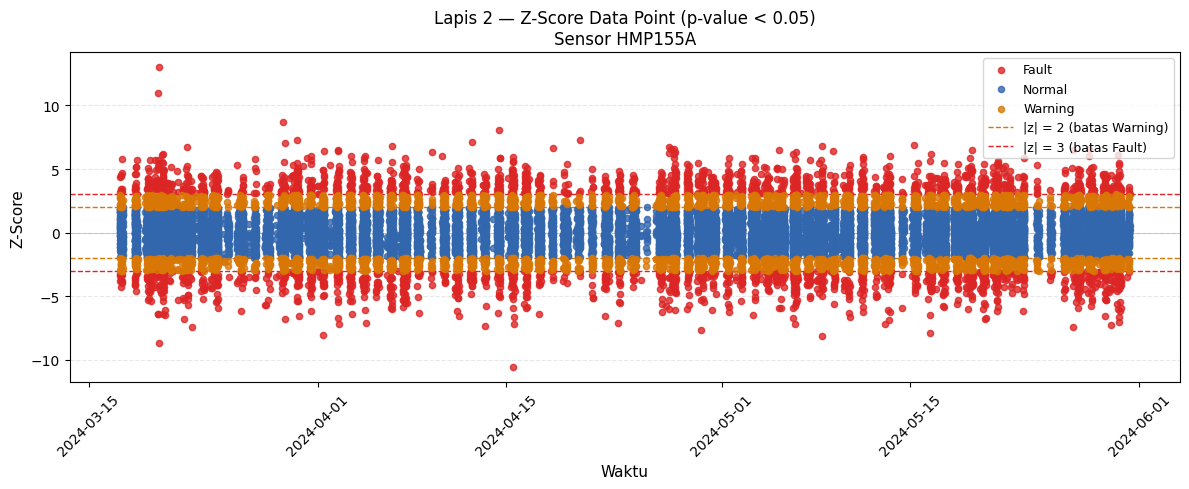

Data masuk lapis 2 : 23423
status
Normal     16563
Warning     3969
Fault       2891
Name: count, dtype: int64


In [ ]:
# hanya data yang masuk lapis 2 (p_value < 0.05)
df_lapis2 = df_deteksi[df_deteksi['p_value'] < 0.05].copy()

fig, ax = plt.subplots(figsize=(12, 5))

warna = {'Normal': '#3266ad', 'Warning': '#d97706', 'Fault': '#dc2626'}

for status, group in df_lapis2.groupby('status'):
    ax.scatter(group.index, group['z_score'],
               color=warna[status], label=status,
               s=20, alpha=0.8, zorder=3)

ax.axhline(y= 2, color='#d97706', linestyle='--', linewidth=1, label='|z| = 2 (batas Warning)')
ax.axhline(y=-2, color='#d97706', linestyle='--', linewidth=1)
ax.axhline(y= 3, color='#dc2626', linestyle='--', linewidth=1, label='|z| = 3 (batas Fault)')
ax.axhline(y=-3, color='#dc2626', linestyle='--', linewidth=1)
ax.axhline(y= 0, color='gray',    linestyle='-',  linewidth=0.5, alpha=0.5)

ax.set_xlabel('Waktu', fontsize=11)
ax.set_ylabel('Z-Score', fontsize=11)
ax.set_title('Lapis 2 — Z-Score Data Point (p-value < 0.05)\nSensor HMP155A', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_lapis2_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Data masuk lapis 2 : {len(df_lapis2)}')
print(df_lapis2['status'].value_counts())

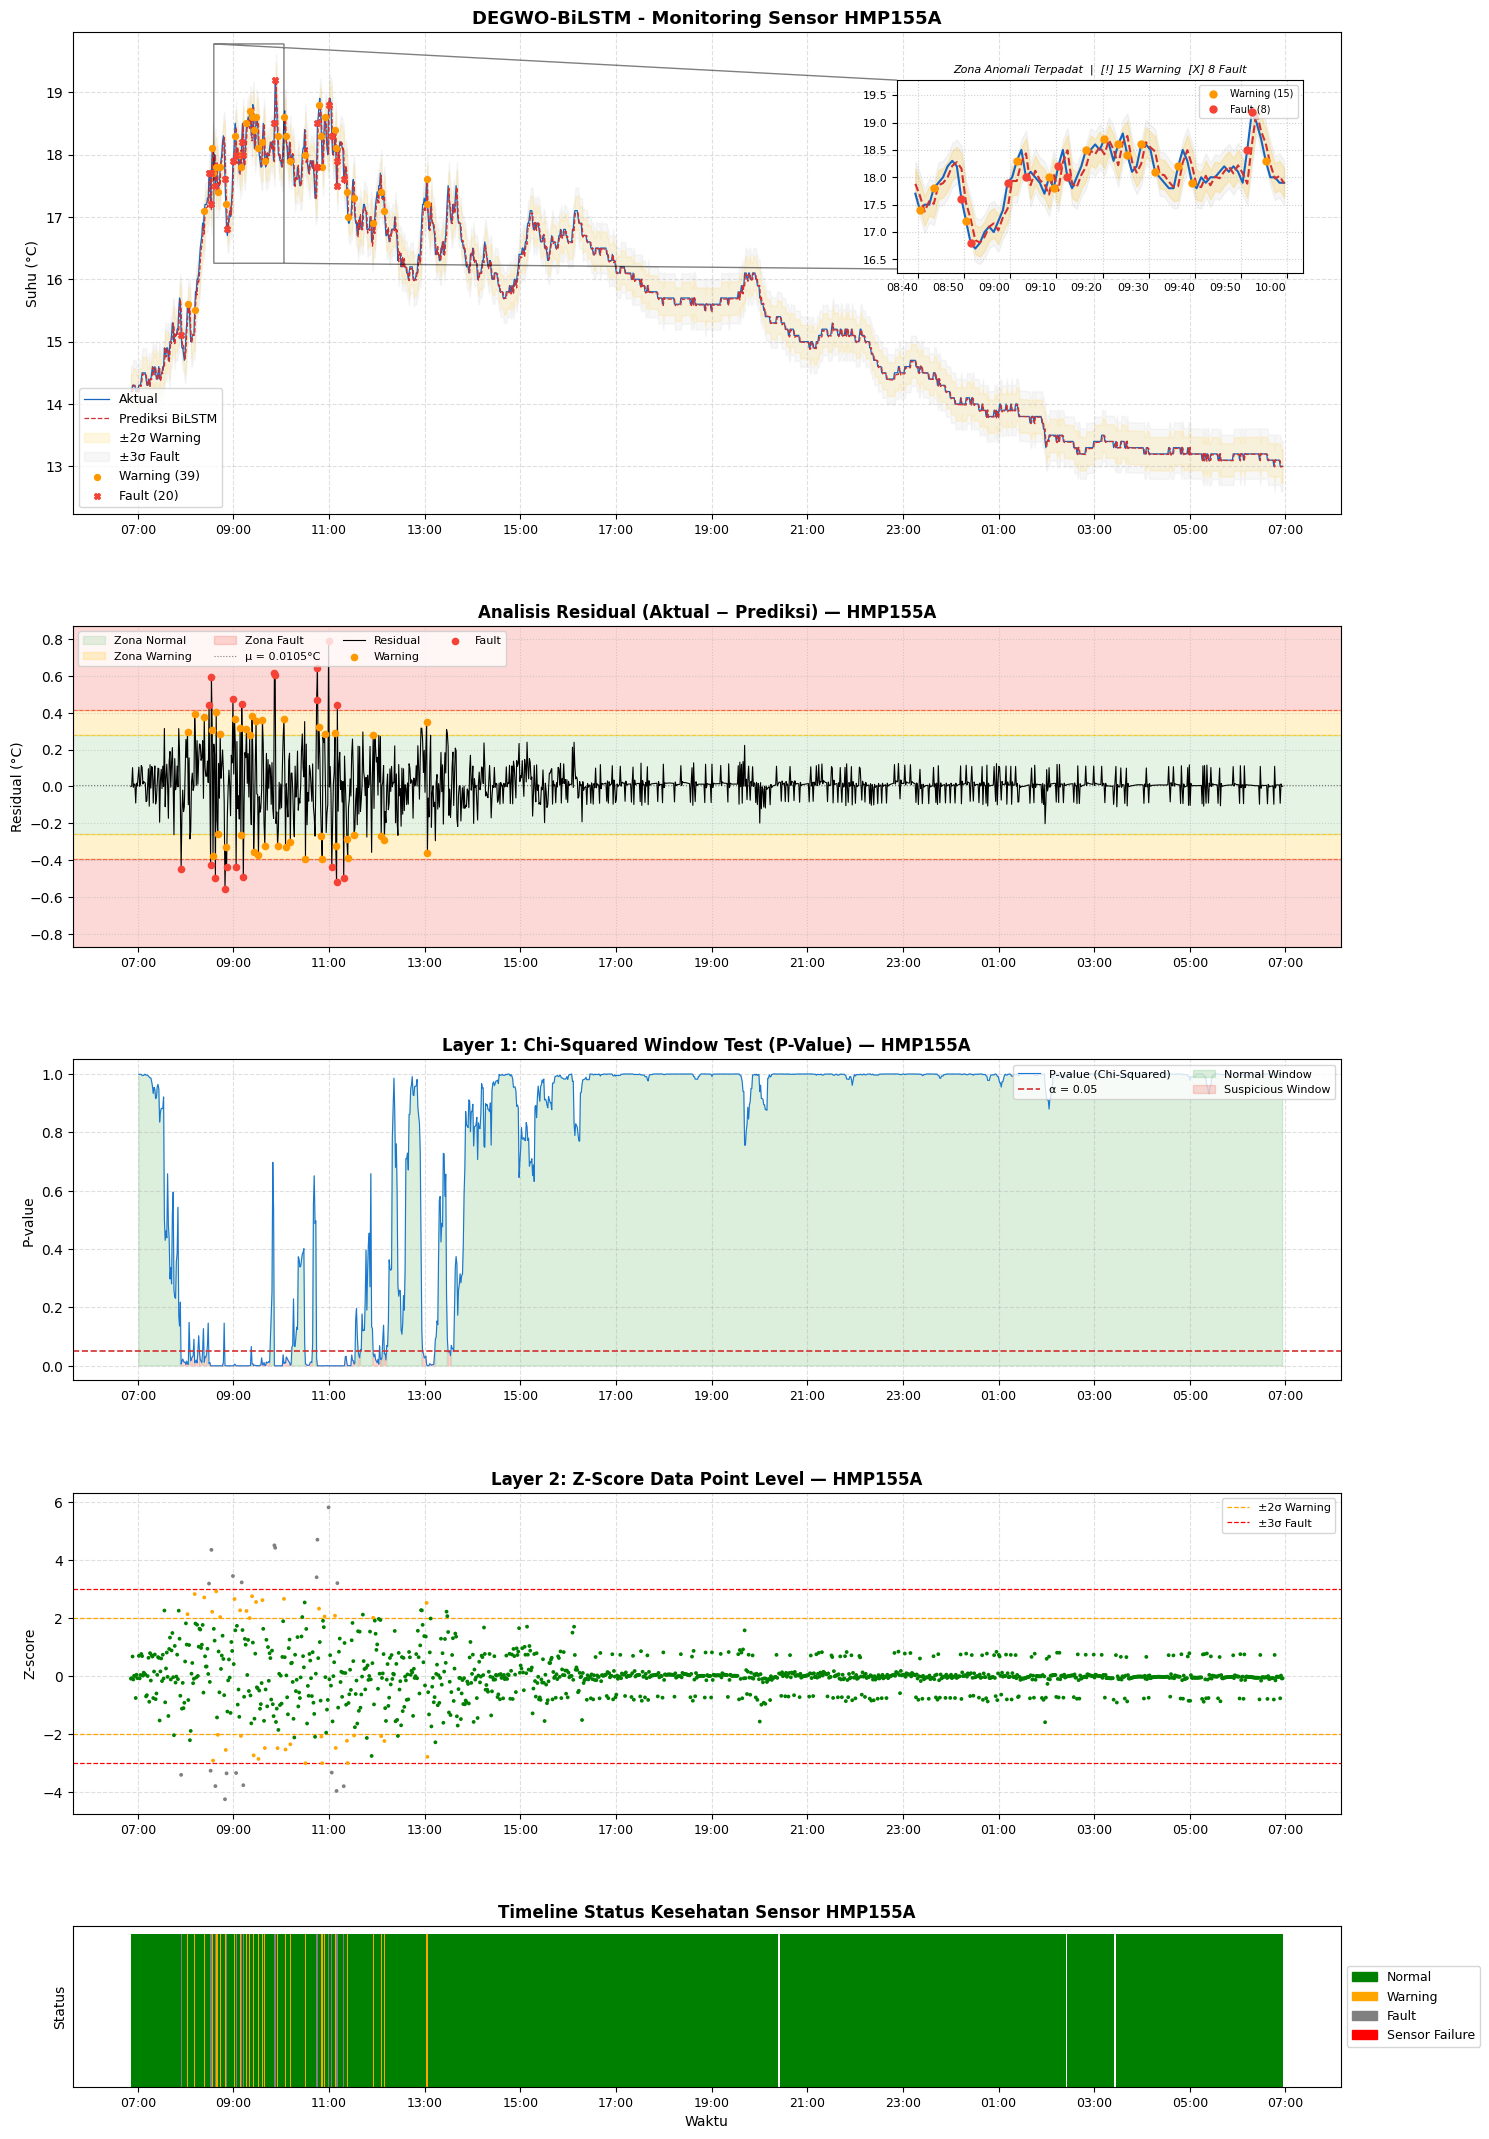

Dashboard disimpan: dashboard_monitoring_DB_HMP155A.png


In [ ]:
sample    = min(1440, len(df_deteksi))
ti        = df_deteksi.index[:sample]
color_map = {'Normal': 'green', 'Warning': 'orange', 'Fault': 'grey'}

pred_s = df_deteksi['prediksi'][:sample].values
act_s  = df_deteksi['aktual'][:sample].values
res_s  = df_deteksi['residual'][:sample].values
z_s    = df_deteksi['z_score'][:sample].values
p_s    = df_deteksi['p_value'][:sample].values
stat_s = df_deteksi['status'][:sample].values
fail_s = df_deteksi['sensor_failure'][:sample].values

res_warn_upper  =  2 * sigma + mu_residual
res_warn_lower  = -2 * sigma + mu_residual
res_fault_upper =  3 * sigma + mu_residual
res_fault_lower = -3 * sigma + mu_residual

y_lim_res = max(
    abs(res_fault_upper) * 1.2,
    abs(res_fault_lower) * 1.2,
    np.abs(res_s).max() * 1.1
)

w_mask = (stat_s == 'Warning')
e_mask = (stat_s == 'Fault')

fig = plt.figure(figsize=(15, 22))
gs  = gridspec.GridSpec(5, 1, height_ratios=[1.5, 1, 1, 1, 0.5])

# ═══════════════════════════════════════════════════════════════════
# PLOT 1: Actual vs Predicted + Interval
# Interval = pred + mu ± k*sigma (konsisten dengan z-score)
# ═══════════════════════════════════════════════════════════════════
ax0 = plt.subplot(gs[0])

ax0.plot(ti, act_s,  color='#1565C0', linewidth=0.9, label='Aktual')
ax0.plot(ti, pred_s, color='#D32F2F', linewidth=0.9,
         linestyle='--', label='Prediksi BiLSTM')

# Band ±2σ: antara pred+mu-2σ dan pred+mu+2σ
ax0.fill_between(
    ti,
    pred_s + mu_residual - 2*sigma,
    pred_s + mu_residual + 2*sigma,
    alpha=0.12, color='#FFC107', label='±2σ Warning'
)
# Band ±3σ: antara pred+mu-3σ dan pred+mu+3σ
ax0.fill_between(
    ti,
    pred_s + mu_residual - 3*sigma,
    pred_s + mu_residual + 3*sigma,
    alpha=0.08, color='#9E9E9E', label='±3σ Fault'
)

# Scatter dari status df_deteksi
ax0.scatter(ti[w_mask], act_s[w_mask],
            color='#FF9800', s=18, zorder=6, marker='o',
            label=f'Warning ({w_mask.sum()})')
ax0.scatter(ti[e_mask], act_s[e_mask],
            color='#F44336', s=18, zorder=6, marker='X',
            label=f'Fault ({e_mask.sum()})')

ax0.set_ylabel('Suhu (°C)')
ax0.set_title('DEGWO-BiLSTM - Monitoring Sensor HMP155A',
              fontweight='bold', fontsize=13)
ax0.legend(loc='lower left', fontsize=9)
ax0.grid(True, linestyle='--', alpha=0.4)

# ── Inset Zoom ────────────────────────────────────────────────────
anomaly_indices = np.where(w_mask | e_mask)[0]
ax_inset = ax0.inset_axes([0.65, 0.5, 0.32, 0.4])

if len(anomaly_indices) > 0:
    clusters, cluster = [], [anomaly_indices[0]]
    for i in range(1, len(anomaly_indices)):
        if anomaly_indices[i] - anomaly_indices[i-1] <= 5:
            cluster.append(anomaly_indices[i])
        else:
            clusters.append(cluster)
            cluster = [anomaly_indices[i]]
    clusters.append(cluster)

    best    = max(clusters, key=lambda c: len(c))
    pad     = max(15, int((best[-1] - best[0]) * 0.5))
    zs      = max(0, best[0] - pad)
    ze      = min(sample, best[-1] + pad + 1)

    ti_z, act_z, pred_z = ti[zs:ze], act_s[zs:ze], pred_s[zs:ze]
    stat_z = stat_s[zs:ze]

    ax_inset.plot(ti_z, act_z,  color='#1565C0', linewidth=1.5)
    ax_inset.plot(ti_z, pred_z, color='#D32F2F', linewidth=1.5,
                  linestyle='--')
    ax_inset.fill_between(ti_z,
        pred_z + mu_residual - 2*sigma,
        pred_z + mu_residual + 2*sigma,
        alpha=0.2, color='#FFC107')
    ax_inset.fill_between(ti_z,
        pred_z + mu_residual - 3*sigma,
        pred_z + mu_residual + 3*sigma,
        alpha=0.1, color='#9E9E9E')

    w_z = (stat_z == 'Warning')
    e_z = (stat_z == 'Fault')
    if w_z.any():
        ax_inset.scatter(ti_z[w_z], act_z[w_z],
                         color='#FF9800', s=25, zorder=6,
                         label=f'Warning ({w_z.sum()})')
    if e_z.any():
        ax_inset.scatter(ti_z[e_z], act_z[e_z],
                         color='#F44336', s=25, zorder=6,
                         label=f'Fault ({e_z.sum()})')

    ax_inset.set_title(
        f'Zona Anomali Terpadat  |  '
        f'[!] {w_z.sum()} Warning  [X] {e_z.sum()} Fault',
        fontsize=8, style='italic')
    ax0.indicate_inset_zoom(ax_inset, edgecolor='black', alpha=0.5)

else:
    zoom_n = min(180, sample)
    ax_inset.plot(ti[:zoom_n], act_s[:zoom_n],
                  color='#1565C0', linewidth=1.5)
    ax_inset.plot(ti[:zoom_n], pred_s[:zoom_n],
                  color='#D32F2F', linewidth=1.5, linestyle='--')
    ax_inset.set_title('Zoom: Semua Data Normal ✅',
                        fontsize=8, style='italic')

ax_inset.grid(True, linestyle=':', alpha=0.6)
ax_inset.tick_params(axis='both', which='major', labelsize=8)
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_inset.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax_inset.xaxis.get_majorticklabels(), rotation=0, ha='right')
ax_inset.legend(loc='upper right', fontsize=7)

# ═══════════════════════════════════════════════════════════════════
# PLOT 2: Residual Analysis
# ═══════════════════════════════════════════════════════════════════
ax1 = plt.subplot(gs[1], sharex=ax0)

# Zona background
ax1.axhspan(res_warn_lower,  res_warn_upper,
            alpha=0.15, color='#4CAF50', label='Zona Normal')
ax1.axhspan(res_warn_upper,  res_fault_upper,
            alpha=0.20, color='#FFC107', label='Zona Warning')
ax1.axhspan(res_fault_lower, res_warn_lower,
            alpha=0.20, color='#FFC107')
ax1.axhspan(res_fault_upper, y_lim_res,
            alpha=0.20, color='#F44336', label='Zona Fault')
ax1.axhspan(-y_lim_res,      res_fault_lower,
            alpha=0.20, color='#F44336')


for val, col in [
    (res_warn_upper,  '#FFC107'),
    (res_warn_lower,  '#FFC107'),
    (res_fault_upper, '#F44336'),
    (res_fault_lower, '#F44336'),
]:
    ax1.axhline(val, color=col, linestyle='--', linewidth=0.8, alpha=0.7)

ax1.axhline(mu_residual, color='black', linestyle=':',
            linewidth=0.8, alpha=0.5,
            label=f'μ = {mu_residual:.4f}°C')

ax1.plot(ti, res_s, color='black', linewidth=0.8, label='Residual')


ax1.scatter(ti[w_mask], res_s[w_mask],
            color='#FF9800', s=20, zorder=5, label='Warning')
ax1.scatter(ti[e_mask], res_s[e_mask],
            color='#F44336', s=20, zorder=5, label='Fault')

ax1.set_ylim(-y_lim_res, y_lim_res)
ax1.set_ylabel('Residual (°C)')
ax1.set_title('Analisis Residual (Aktual − Prediksi) — HMP155A',
              fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=4)
ax1.grid(True, linestyle=':', alpha=0.5)

# ═══════════════════════════════════════════════════════════════════
# PLOT 3: P-Value — Layer 1 Window Level
# ═══════════════════════════════════════════════════════════════════
ax2 = plt.subplot(gs[2], sharex=ax0)

ax2.plot(ti, p_s, color='#1976D2', linewidth=0.8,
         label='P-value (Chi-Squared)')
ax2.axhline(0.05, color='#D32F2F', linestyle='--',
            linewidth=1.2, label='α = 0.05')
ax2.fill_between(ti, 0, p_s,
                 where=(p_s >= 0.05),
                 alpha=0.2, color='#4CAF50', label='Normal Window')
ax2.fill_between(ti, 0, p_s,
                 where=(p_s <  0.05),
                 alpha=0.2, color='#F44336', label='Suspicious Window')

ax2.set_ylabel('P-value')
ax2.set_ylim(-0.05, 1.05)
ax2.set_title('Layer 1: Chi-Squared Window Test (P-Value) — HMP155A',
              fontweight='bold')
ax2.legend(loc='upper right', fontsize=8, ncol=2)
ax2.grid(True, linestyle='--', alpha=0.4)

# ═══════════════════════════════════════════════════════════════════
# PLOT 4: Z-Score — Layer 2 Point Level
# ═══════════════════════════════════════════════════════════════════
ax3 = plt.subplot(gs[3], sharex=ax0)

c_pt = [color_map[s] for s in stat_s]
ax3.scatter(ti, z_s, c=c_pt, s=3, zorder=3)

for val, color, label in [
    (2, 'orange', '±2σ Warning'),
    (3, 'red',    '±3σ Fault')
]:
    ax3.axhline( val, color=color, linestyle='--',
                linewidth=0.9, label=label)
    ax3.axhline(-val, color=color, linestyle='--', linewidth=0.9)

ax3.set_ylabel('Z-score')
ax3.set_title('Layer 2: Z-Score Data Point Level — HMP155A',
              fontweight='bold')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.4)

# ═══════════════════════════════════════════════════════════════════
# PLOT 5: Status Timeline
# ═══════════════════════════════════════════════════════════════════
ax4 = plt.subplot(gs[4], sharex=ax0)

c_bar = [color_map[s] for s in stat_s]
ax4.bar(ti, [1] * sample, color=c_bar, width=1/1440)

fail_times = ti[fail_s]
if len(fail_times) > 0:
    ax4.bar(fail_times, [1.0] * len(fail_times),
            color='red', width=1/1440, label='Sensor Failure')

ax4.set_ylabel('Status')
ax4.set_yticks([])
ax4.set_xlabel('Waktu')
ax4.set_title('Timeline Status Kesehatan Sensor HMP155A',
              fontweight='bold')

p_normal  = mpatches.Patch(color='green',  label='Normal')
p_warning = mpatches.Patch(color='orange', label='Warning')
p_fault   = mpatches.Patch(color='grey',   label='Fault')
p_failure = mpatches.Patch(color='red',    label='Sensor Failure')
ax4.legend(
    handles=[p_normal, p_warning, p_fault, p_failure],
    loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9
)

for ax in [ax0, ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.tick_params(axis='x', rotation=0, labelsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.35)
plt.savefig('dashboard_monitoring_DB_HMP155A.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard disimpan: dashboard_monitoring_DB_HMP155A.png")

## Cell 22 — Distribusi Residual & Proporsi Status

=== Distribusi Status Kondisi Sensor HMP155A ===
  Normal    : 100624 data (93.62%)
  Fault     :   2891 data (2.69%)
  Total     : 107484 data

  Sensor Failure : 172 data point


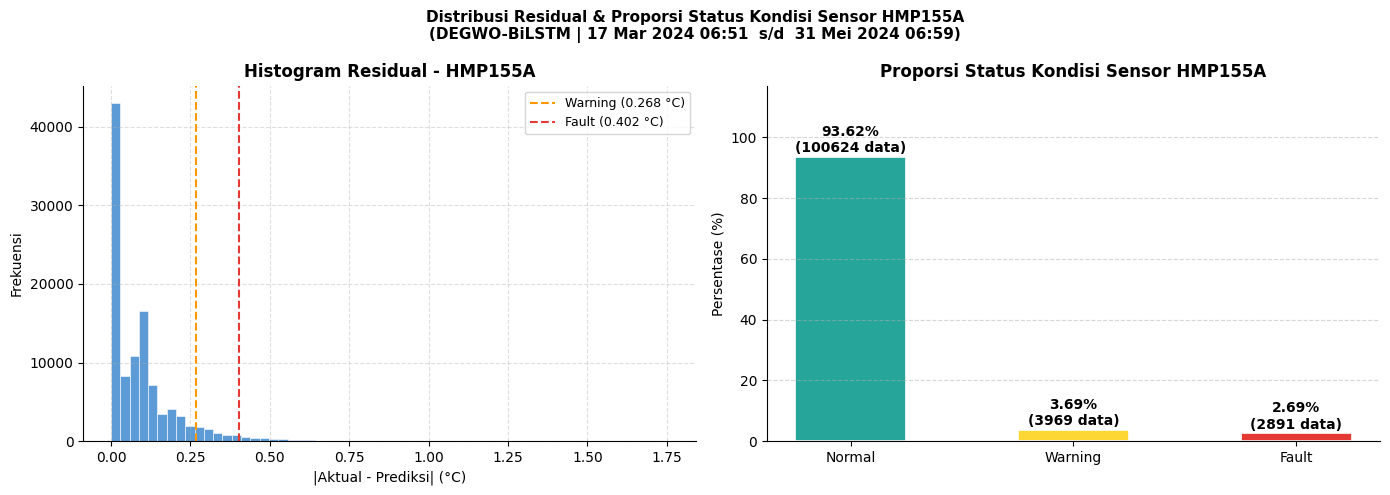

Grafik distribusi disimpan: distribusi_status_HMP155A.png
  ✅ Disimpan: distribusi_status_HMP155A.xlsx


In [ ]:
bulan_indo = {
    'Jan': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar', 'Apr': 'Apr', 'May': 'Mei', 'Jun': 'Jun',
    'Jul': 'Jul', 'Aug': 'Agu', 'Sep': 'Sep', 'Oct': 'Okt', 'Nov': 'Nov', 'Dec': 'Des'
}

def format_tgl_indo(dt):
    tgl_str = dt.strftime('%d %b %Y %H:%M')
    for eng, indo in bulan_indo.items():
        tgl_str = tgl_str.replace(eng, indo)
    return tgl_str

tgl_mulai = format_tgl_indo(df_deteksi.index[0])
tgl_akhir = format_tgl_indo(df_deteksi.index[-1])
total     = len(df_deteksi)

status_colors = {'Normal': '#26A69A', 'Warning': '#FDD835', 'Fault': '#E53935'}
status_counts = df_deteksi['status'].value_counts()
labels_status = ['Normal', 'Warning', 'Fault']
sizes         = [status_counts.get(s, 0) for s in labels_status]
percents      = [s / total * 100 for s in sizes]
colors_plot   = [status_colors[s] for s in labels_status]

print('=== Distribusi Status Kondisi Sensor HMP155A ===')
for nama, n, pct in zip(labels_status, sizes, percents):
    print(f'  {nama:<10}: {n:>6} data ({pct:.2f}%)')
print(f'  {"Total":<10}: {total:>6} data')
print(f'\n  Sensor Failure : {df_deteksi["sensor_failure"].sum()} data point')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Distribusi Residual & Proporsi Status Kondisi Sensor HMP155A\n'
    f'(DEGWO-BiLSTM | {tgl_mulai}  s/d  {tgl_akhir})',
    fontsize=11, fontweight='bold'
)

# ── Kiri: Histogram Residual ──────────────────────────────────────
abs_res = np.abs(df_deteksi['residual'].values)
axes[0].hist(abs_res, bins=60, color='#5C9BD6', edgecolor='white', linewidth=0.4)
axes[0].axvline(2 * sigma, color='#FF9800', linestyle='--', linewidth=1.5,
                label=f'Warning ({2*sigma:.3f} °C)')
axes[0].axvline(3 * sigma, color='#E53935', linestyle='--', linewidth=1.5,
                label=f'Fault ({3*sigma:.3f} °C)')
axes[0].set_xlabel('|Aktual - Prediksi| (°C)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Histogram Residual - HMP155A', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Kanan: Bar Chart Proporsi Status ─────────────────────────────
bars = axes[1].bar(labels_status, percents, color=colors_plot,
                   width=0.5, edgecolor='white', linewidth=1.2)
for bar, pct, n in zip(bars, percents, sizes):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.2f}%\n({n} data)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[1].set_title('Proporsi Status Kondisi Sensor HMP155A', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_ylim(0, max(percents) * 1.25 if max(percents) > 0 else 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('distribusi_status_HMP155A.png', dpi=150)
plt.show()
print('Grafik distribusi disimpan: distribusi_status_HMP155A.png')

df_dist = pd.DataFrame({
    'Status'     : labels_status,
    'Jumlah'     : sizes,
    'Persentase' : percents
})
save_to_excel(df_dist, 'distribusi_status_HMP155A.xlsx', sheet_name='Distribusi Status', index=False)